# Weeks 1–4 · Preprocessing and baseline validation
**Pre-specified models:** training-prior/majority DummyClassifier and L2 Logistic Regression (C=1, no class weighting, threshold=0.5). No parameter search, fitted calibration model, XGBoost, or SHAP at this stage.

Telecom: five development folds; Iranian folds keep identical candidate profiles together. Retail: four expanding temporal validation origins. No final-test labels or performance are computed.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'config/study_design.json').exists())
sys.path.insert(0,str(ROOT/'src'))
from audit_utils import *
from baseline_utils import *
TABLES=ROOT/'outputs/tables';FIGS=ROOT/'outputs/figures'
pd.set_option('display.width',180);pd.set_option('display.max_columns',30)
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
print('Stage: Weeks 1-4 / development-only analyses')


Stage: Weeks 1-4 / development-only analyses


## 1. Fold-safe pipeline
Numeric median imputation with missingness indicators, standardization, and one-hot encoding are learned from each training partition. Retail nonnegative counts, recency and spending use a fixed log1p transformation before scaling. Categorical unknowns are ignored at transform time. Customer IDs, future labels, and outcome-window metadata are excluded.

IBM numeric fields: tenure, MonthlyCharges, TotalCharges. Other IBM predictors are categorical. Iranian categorical fields: Complains, Age Group, Tariff Plan; Status and Customer Value are excluded from the primary baseline. The remaining Iranian fields are numeric.

In [2]:
dev=telecom_development(ROOT)
for name,d in dev.items():
    pp=preprocessing(d['X'],d['categorical'])
    print(name, len(d['X'].columns),'raw predictors',d['X'].columns.tolist())
    assert not any(c in d['X'] for c in ['Churn','customerID','Status','Customer Value'])
print('No final-test data are passed into any model fit or metric.')


ibm 19 raw predictors ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
iranian 11 raw predictors ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Age']
No final-test data are passed into any model fit or metric.


In [3]:
tm,tp,tc,fold_ids=telecom_baselines(ROOT)
tm.to_csv(TABLES/'baseline_telecom_fold_metrics.csv',index=False)
tp.to_csv(TABLES/'baseline_telecom_oof_predictions.csv',index=False)
tc.to_csv(TABLES/'baseline_telecom_coefficients.csv',index=False)
fold_ids.to_csv(TABLES/'telecom_development_fold_assignments.csv',index=False)
print(tm[['dataset','fold','model','n','roc_auc','average_precision','accuracy','recall_05','brier']].round(4).to_string(index=False))
assert not tp.duplicated(['dataset','model','row_id']).any()


dataset fold               model    n  roc_auc  average_precision  accuracy  recall_05  brier
    ibm    1    Prior / majority 1127   0.5000             0.2653    0.7347     0.0000 0.1949
    ibm    1 Logistic Regression 1127   0.8350             0.6243    0.7977     0.5518 0.1403
    ibm    2    Prior / majority 1127   0.5000             0.2653    0.7347     0.0000 0.1949
    ibm    2 Logistic Regression 1127   0.8422             0.6450    0.7906     0.5318 0.1376
    ibm    3    Prior / majority 1127   0.5000             0.2653    0.7347     0.0000 0.1949
    ibm    3 Logistic Regression 1127   0.8416             0.6711    0.8039     0.5318 0.1365
    ibm    4    Prior / majority 1127   0.5000             0.2653    0.7347     0.0000 0.1949
    ibm    4 Logistic Regression 1127   0.8504             0.6283    0.8083     0.5485 0.1346
    ibm    5    Prior / majority 1126   0.5000             0.2655    0.7345     0.0000 0.1950
    ibm    5 Logistic Regression 1126   0.8477             0

## 2. Retail forward validation
At each origin, train on all earlier customer snapshots whose labels are already fully observed. Validate on the next origin. Some customers recur over time, as in repeated scoring of existing customers; they are not treated as independent when interpreting variability.

Training/validation feature windows can overlap in calendar time. The critical boundary is that all training labels are observable before validation scoring. Each customer-origin uses only pre-cutoff features. The original final cutoff of 2011-09-01 remains reserved.

In [4]:
valid=pd.read_csv(ROOT/'data/processed/retail_valid_purchases.csv.gz',parse_dates=['invoice_date'],dtype={'customer_id':str,'invoice':str,'stock_code':str})
rm,rp,rc,windows,cohorts=retail_baselines(ROOT,valid)
rm.to_csv(TABLES/'baseline_retail_fold_metrics.csv',index=False)
rp.to_csv(TABLES/'baseline_retail_temporal_predictions.csv',index=False)
rc.to_csv(TABLES/'baseline_retail_coefficients.csv',index=False)
windows.to_csv(TABLES/'retail_rolling_validation_plan.csv',index=False)
pd.concat(cohorts,ignore_index=True).to_csv(ROOT/'data/processed/retail_development_snapshots.csv.gz',index=False,compression='gzip')
assert '2011-09-01' not in rp.fold.unique()
print(windows.to_string(index=False))
print(rm[['fold','model','train_n','n','roc_auc','average_precision','accuracy','recall_05','brier']].round(4).to_string(index=False))


      fold                               train_origins  train_n  train_unique_customers  validation_n validation_label_end train_latest_label_end
2010-09-01                                  2010-06-01     2669                    2669          2831  2010-11-30T00:00:00    2010-08-30T00:00:00
2010-12-01                       2010-06-01,2010-09-01     5500                    3294          3479  2011-03-01T00:00:00    2010-11-30T00:00:00
2011-03-01            2010-06-01,2010-09-01,2010-12-01     8979                    4250          3349  2011-05-30T00:00:00    2011-03-01T00:00:00
2011-06-01 2010-06-01,2010-09-01,2010-12-01,2011-03-01    12328                    4522          2659  2011-08-30T00:00:00    2011-05-30T00:00:00
      fold               model  train_n    n  roc_auc  average_precision  accuracy  recall_05  brier
2010-09-01    Prior / majority     2669 2831   0.5000             0.3808    0.3808     1.0000 0.2502
2010-09-01 Logistic Regression     2669 2831   0.7191             0.

## 3. Comparable reporting, with different validation designs
Fold means and standard deviations describe variation; they are not confidence intervals. Retail temporal folds are correlated and reflect different calendar periods. Average precision depends on outcome prevalence, so scores are not an industry league table. All threshold metrics use 0.5 without tuning. The prior model has constant probabilities and no meaningful ranking at a 10% outreach capacity.

In [5]:
all_metrics=pd.concat([tm,rm],ignore_index=True)
all_metrics.to_csv(TABLES/'baseline_all_fold_metrics.csv',index=False)
metric_names=['roc_auc','average_precision','accuracy','precision_05','recall_05','f1_05','brier','log_loss','precision_top10','recall_top10','lift_top10','retention_error_pp']
summary=[]
for (dataset,model),g in all_metrics.groupby(['dataset','model']):
    row={'dataset':dataset,'model':model,'folds':len(g),'validation_observations':int(g.n.sum()),'mean_positive_rate':g.positive_rate.mean()}
    for m in metric_names:row[m+'_mean']=g[m].mean();row[m+'_sd']=g[m].std(ddof=1)
    row['retention_mae_pp']=g.retention_error_pp.abs().mean()
    summary.append(row)
summary=pd.DataFrame(summary);summary.to_csv(TABLES/'baseline_summary.csv',index=False)
print(summary[['dataset','model','folds','roc_auc_mean','roc_auc_sd','average_precision_mean','accuracy_mean','recall_05_mean','brier_mean']].round(4).to_string(index=False))
all_predictions=pd.concat([tp,rp],ignore_index=True)
all_predictions.to_csv(TABLES/'baseline_validation_predictions.csv',index=False)
print('Every validation prediction is available for metric reproduction.')


dataset               model  folds  roc_auc_mean  roc_auc_sd  average_precision_mean  accuracy_mean  recall_05_mean  brier_mean
    ibm Logistic Regression      5        0.8434      0.0060                  0.6502         0.8016          0.5438      0.1365
    ibm    Prior / majority      5        0.5000      0.0000                  0.2654         0.7346          0.0000      0.1949
iranian Logistic Regression      5        0.9294      0.0057                  0.7546         0.9005          0.4361      0.0708
iranian    Prior / majority      5        0.5000      0.0000                  0.1575         0.8425          0.0000      0.1327
 retail Logistic Regression      4        0.7429      0.0160                  0.7082         0.6694          0.7173      0.2131
 retail    Prior / majority      4        0.5000      0.0000                  0.5195         0.4592          0.7500      0.2545
Every validation prediction is available for metric reproduction.


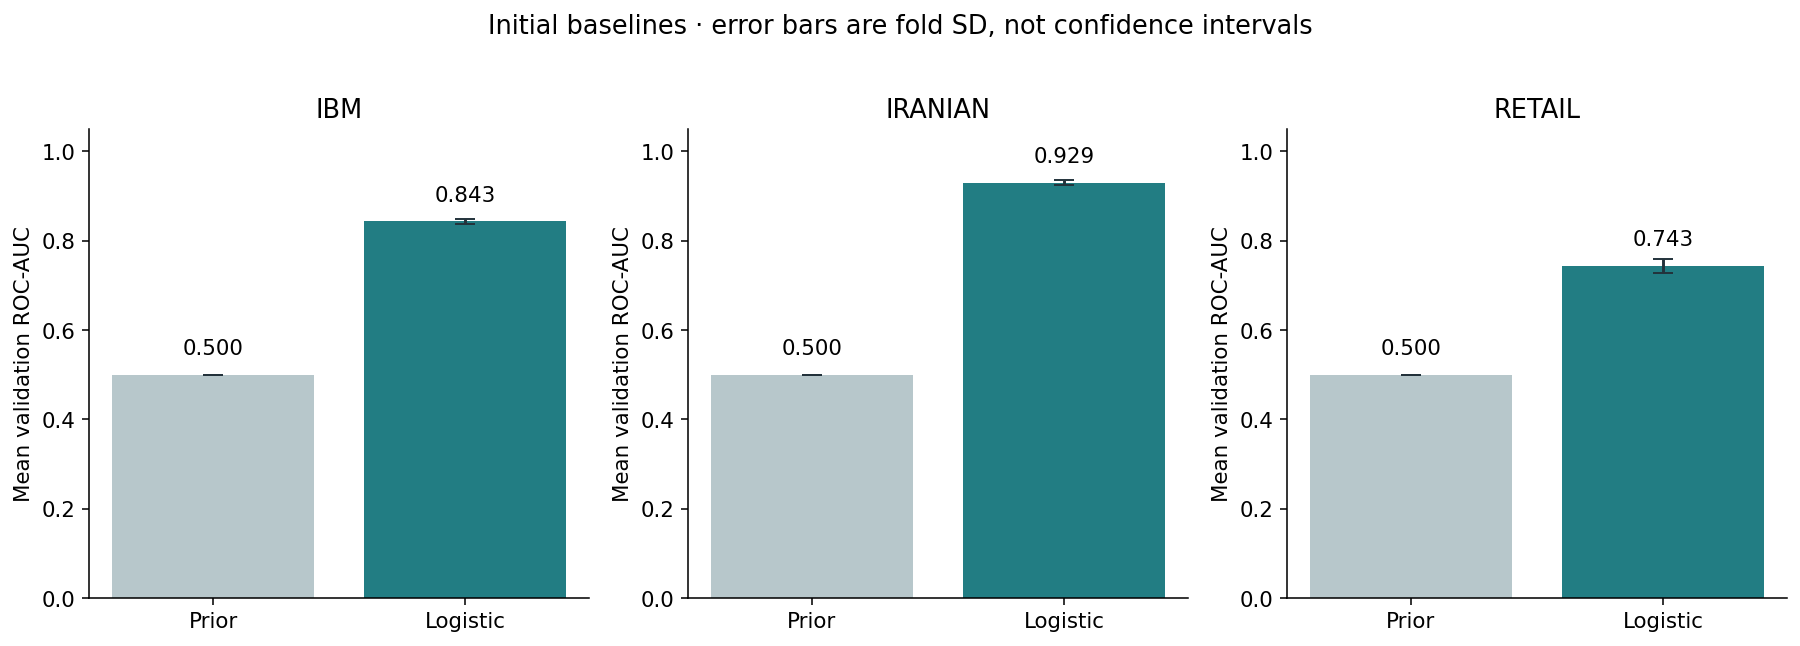

In [6]:
fig,axs=plt.subplots(1,3,figsize=(13,4.5))
for ax,dataset in zip(axs,['ibm','iranian','retail']):
    ss=summary.loc[summary.dataset.eq(dataset)].set_index('model').loc[['Prior / majority','Logistic Regression']]
    ax.bar([0,1],ss.roc_auc_mean,color=['#B7C7CB','#227D83'])
    ax.errorbar([0,1],ss.roc_auc_mean,yerr=ss.roc_auc_sd,fmt='none',ecolor='#23323B',capsize=5)
    ax.set(xticks=[0,1],xticklabels=['Prior','Logistic'],ylim=(0,1.05),title=dataset.upper(),ylabel='Mean validation ROC-AUC')
    for i,v in enumerate(ss.roc_auc_mean):ax.text(i,v+.045,f'{v:.3f}',ha='center')
fig.suptitle('Initial baselines · error bars are fold SD, not confidence intervals',y=1.02)
fig.tight_layout();fig.savefig(FIGS/'baseline_auc.png',dpi=170,bbox_inches='tight')


## 4. Diagnostics without post-hoc tuning
Reliability bins assess raw baseline probabilities; no calibration mapping is fitted. Inspection guides the next research stage but does not change these reported baseline models.

{
  "period": "Weeks 1-4",
  "datasets": 3,
  "notebook_stage": "baseline validation",
  "telecom_folds_per_dataset": 5,
  "retail_temporal_folds": 4,
  "classifier_types": [
    "Prior / majority",
    "Logistic Regression"
  ],
  "fit_count": 28,
  "hyperparameter_search": false,
  "final_test_evaluated": false,
  "retail_final_test_labels_constructed": false,
  "xgboost_fitted": false,
  "shap_computed": false,
  "convergence_warnings": 0
}


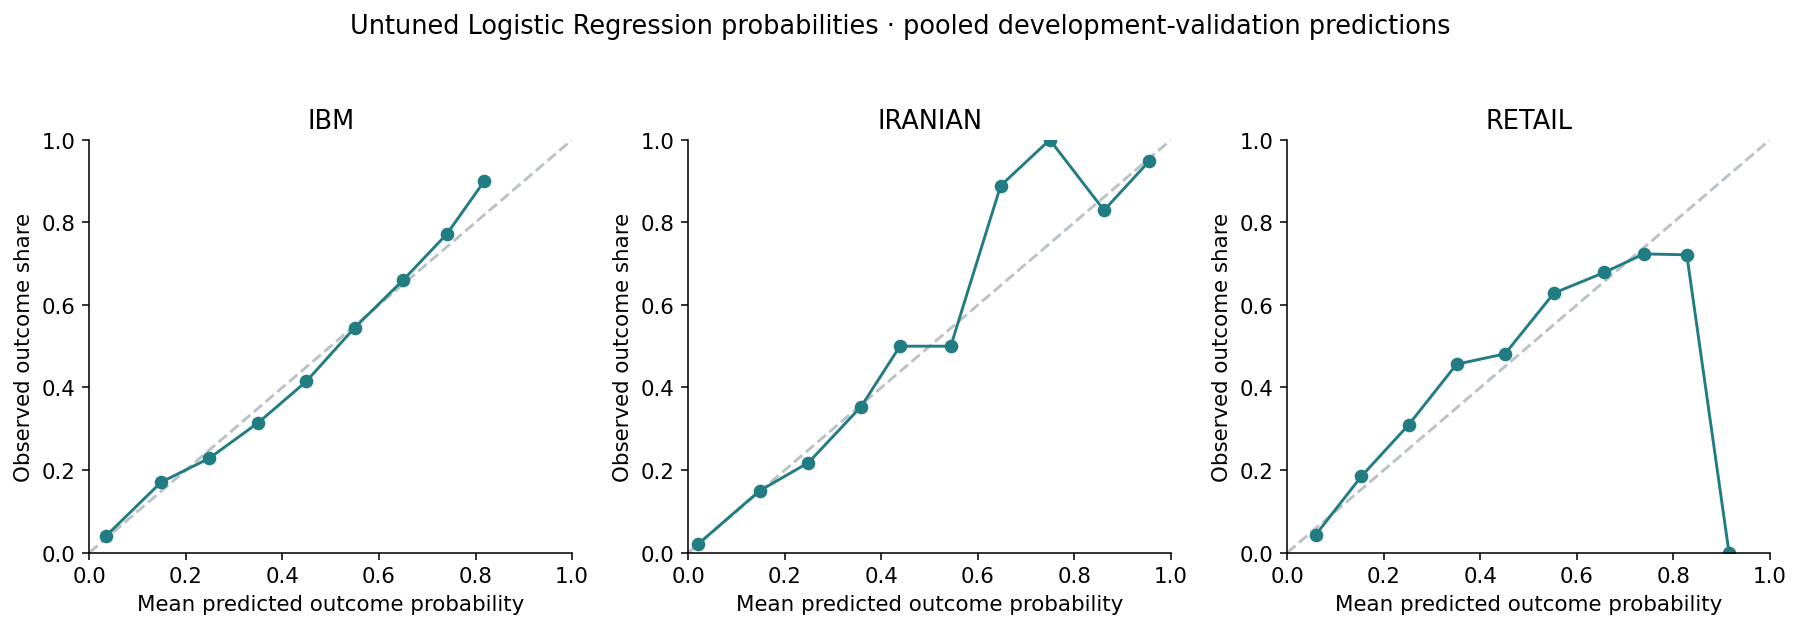

In [7]:
calibration=[]
fig,axs=plt.subplots(1,3,figsize=(13,4.3))
for ax,dataset in zip(axs,['ibm','iranian','retail']):
    z=all_predictions.loc[(all_predictions.dataset==dataset)&(all_predictions.model=='Logistic Regression')].copy()
    z['bin']=pd.cut(z.p,np.linspace(0,1,11),include_lowest=True)
    b=z.groupby('bin',observed=True).agg(n=('y','size'),mean_p=('p','mean'),observed_rate=('y','mean')).reset_index()
    b['bin']=b['bin'].astype(str);b['dataset']=dataset;calibration.append(b)
    ax.plot([0,1],[0,1],'--',color='#BBC3C8');ax.plot(b.mean_p,b.observed_rate,'o-',color='#227D83')
    ax.set(title=dataset.upper(),xlabel='Mean predicted outcome probability',ylabel='Observed outcome share',xlim=(0,1),ylim=(0,1))
fig.suptitle('Untuned Logistic Regression probabilities · pooled development-validation predictions',y=1.04)
fig.tight_layout();fig.savefig(FIGS/'baseline_reliability.png',dpi=170,bbox_inches='tight')
pd.concat(calibration,ignore_index=True).to_csv(TABLES/'baseline_reliability_bins.csv',index=False)
status={'period':'Weeks 1-4','datasets':3,'notebook_stage':'baseline validation','telecom_folds_per_dataset':5,'retail_temporal_folds':4,
 'classifier_types':['Prior / majority','Logistic Regression'],'fit_count':int(len(all_metrics)),
 'hyperparameter_search':False,'final_test_evaluated':False,'retail_final_test_labels_constructed':False,
 'xgboost_fitted':False,'shap_computed':False,'convergence_warnings':0}
(ROOT/'outputs/weeks1_4_status.json').write_text(json.dumps(status,indent=2))
print(json.dumps(status,indent=2))


## Next stage
Tune and compare XGBoost within the same validation framework; inspect calibration and subgroup errors; assess explanations and feature-group stability. Freeze model and decision policies before one final-test evaluation. A higher risk score does not imply a greater treatment benefit.